In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import make_moons
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

sns.set()

# Ejercicio de clasificación usando kNN
**Aprendizaje de Máquina - CEIA - FIUBA**

Para ilustrar el clasificador k-NN, vamos a usar el dataset sintético **Two Moons**. En lugar de un dataset real, usamos uno generado artificialmente — y eso es deliberado: los datasets sintéticos nos permiten controlar exactamente la forma del problema y observar con claridad qué aprende (y qué no) cada modelo.

## ¿Qué es Two Moons?

El dataset consiste en puntos distribuidos en **dos grupos con forma de luna creciente entrelazada**, uno por clase. La dificultad del problema se regula con el parámetro `noise`, que agrega ruido gaussiano a las posiciones:

- Con `noise=0` las lunas están perfectamente separadas.
- Con `noise` alto se solapan cada vez más.

Usamos `noise=0.3`: separación visible pero con solapamiento en la zona de contacto entre las lunas.

## ¿Por qué es un buen ejemplo?

Este dataset tiene una propiedad fundamental: **ninguna línea recta puede separar ambas clases**. Esto lo convierte en el ejemplo canónico para comparar clasificadores lineales vs. no lineales:

| Tipo de clasificador | Frontera de decisión | ¿Puede resolver Two Moons? |
|---|---|---|
| Lineal (Regresión Logística) | Hiperplano (recta en 2D) | No |
| No lineal (kNN) | Forma libre, basada en vecinos | Sí |

A lo largo de esta notebook veremos exactamente eso.

In [2]:
X, y = make_moons(n_samples=1000, noise=0.3, random_state=42)

moons_df = pd.DataFrame(X, columns=["feature_1", "feature_2"])
moons_df["clase"] = y

El dataset tiene solo dos columnas numéricas que representan la posición de cada punto en el plano, y la columna `clase` (0 o 1) que indica a qué luna pertenece:

In [3]:
moons_df.head()

,feature_1,feature_2,clase
0,-0.171863,0.596249,1
1,1.253283,-0.265414,1
2,0.723224,0.231943,1
3,-0.065198,-0.655194,1
4,-0.799493,0.552935,0


Visualicemos los datos — para un dataset 2D, el scatter plot es suficiente para entender el problema completo:

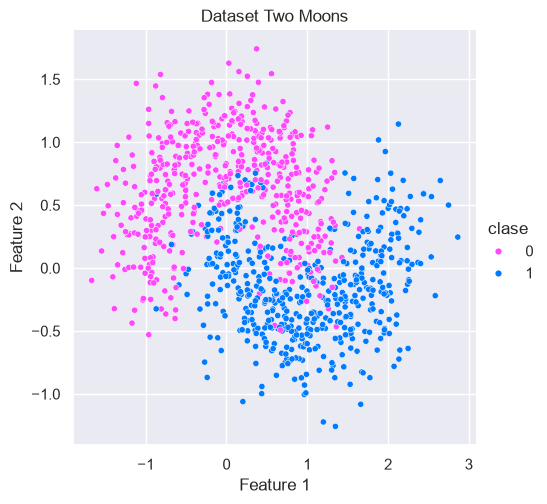

In [4]:
g = sns.relplot(
    data=moons_df,
    x="feature_1",
    y="feature_2",
    hue="clase",
    palette={0: "#ff48fd", 1: "#007aff"},
    kind="scatter",
    legend=True,
    s=20,
)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Dataset Two Moons");

La forma de luna creciente entrelazada es inmediatamente visible. Ambas clases conviven en el mismo espacio de features y no existe ninguna recta que pueda separarlas — cualquier línea recta que se trace dejará puntos del color incorrecto en ambos lados.

Con esto en mente, veamos qué le pasa a la regresión logística cuando intenta resolver este problema.

### Modelo de regresión logística

Para tener un punto de comparación, entrenemos una regresión logística. Este modelo asume que la frontera de decisión es **lineal** (una recta en 2D). Como los datos tienen forma de luna creciente entrelazada, esperamos que le resulte imposible separar bien las clases.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0, stratify=y
)

In [6]:
model_logistic = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(random_state=0))
])

model_logistic.fit(X_train, y_train)
y_pred_logistic = model_logistic.predict(X_test)

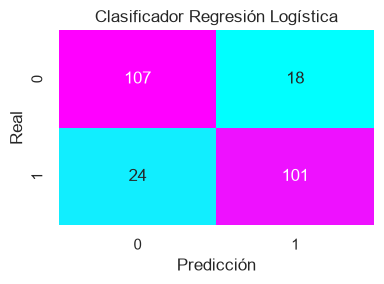

In [7]:
cm_logistic = confusion_matrix(y_test, y_pred_logistic)

fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(cm_logistic, annot=True, fmt="d", cmap="cool", cbar=False, ax=ax)
ax.set_title("Clasificador Regresión Logística")
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

In [8]:
cm_logistic = confusion_matrix(y_test, y_pred_logistic)

print("Clasificador Regresión Logística")
print("-" * 32)

P = cm_logistic[1, :].sum()
N = cm_logistic[0, :].sum()
TP = cm_logistic[1, 1]
TN = cm_logistic[0, 0]

TPR = TP / P
TNR = TN / N
balanced_accuracy = (TPR + TNR) / 2

precision = precision_score(y_test, y_pred_logistic, zero_division=0)
recall = recall_score(y_test, y_pred_logistic, zero_division=0)
f1 = f1_score(y_test, y_pred_logistic, zero_division=0)

print(f"Sensibilidad (Recall): {TPR:.4f}")
print(f"Especificidad:         {TNR:.4f}")
print(f"Exactitud balanceada:  {balanced_accuracy:.4f}")
print(f"Precisión:             {precision:.4f}")
print(f"Recuperación (Recall): {recall:.4f}")
print(f"F1-score:              {f1:.4f}")

Clasificador Regresión Logística
--------------------------------
Sensibilidad (Recall): 0.8080
Especificidad:         0.8560
Exactitud balanceada:  0.8320
Precisión:             0.8487
Recuperación (Recall): 0.8080
F1-score:              0.8279


## Clasificador KNN

Vamos a usar el clasificador KNN de [scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html). A diferencia de la regresión logística, kNN no asume ninguna forma para la frontera de decisión: la construye directamente desde los datos. Veamos si logra capturar la estructura no lineal de las lunas.

In [9]:
classifier_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', KNeighborsClassifier(n_neighbors=15, metric="minkowski", p=2))
])

classifier_knn.fit(X_train, y_train)
y_pred_knn = classifier_knn.predict(X_test)

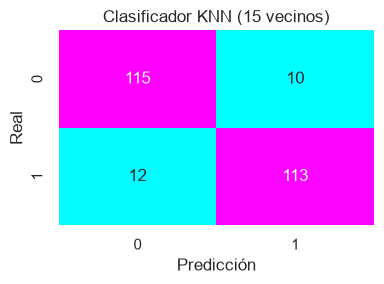

In [10]:
cm_knn = confusion_matrix(y_test, y_pred_knn)

fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(cm_knn, annot=True, fmt="d", cmap="cool", cbar=False, ax=ax)
ax.set_title("Clasificador KNN (15 vecinos)")
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

In [11]:
print("Clasificador KNN (15 vecinos)")
print("-" * 29)

P = cm_knn[1, :].sum()
N = cm_knn[0, :].sum()
TP = cm_knn[1, 1]
TN = cm_knn[0, 0]

TPR_knn = TP / P
TNR_knn = TN / N
balanced_accuracy_knn = (TPR_knn + TNR_knn) / 2

precision_knn = precision_score(y_test, y_pred_knn, zero_division=0)
recall_knn = recall_score(y_test, y_pred_knn, zero_division=0)
f1_knn = f1_score(y_test, y_pred_knn, zero_division=0)

print(f"Sensibilidad (Recall): {TPR_knn:.4f}")
print(f"Especificidad:         {TNR_knn:.4f}")
print(f"Exactitud balanceada:  {balanced_accuracy_knn:.4f}")
print(f"Precisión:             {precision_knn:.4f}")
print(f"Recuperación (Recall): {recall_knn:.4f}")
print(f"F1-score:              {f1_knn:.4f}")

Clasificador KNN (15 vecinos)
-----------------------------
Sensibilidad (Recall): 0.9040
Especificidad:         0.9200
Exactitud balanceada:  0.9120
Precisión:             0.9187
Recuperación (Recall): 0.9040
F1-score:              0.9113


## Comparativa de modelos

Veamos lado a lado las métricas de ambos modelos sobre el conjunto de evaluación:

In [12]:
from sklearn.metrics import balanced_accuracy_score

df_cmp = pd.DataFrame({
    "F1-score": [
        f1_score(y_test, y_pred_logistic),
        f1_score(y_test, y_pred_knn),
    ],
    "Exactitud balanceada": [
        balanced_accuracy_score(y_test, y_pred_logistic),
        balanced_accuracy_score(y_test, y_pred_knn),
    ],
    "Precisión": [
        precision_score(y_test, y_pred_logistic),
        precision_score(y_test, y_pred_knn),
    ],
    "Sensibilidad": [
        recall_score(y_test, y_pred_logistic),
        recall_score(y_test, y_pred_knn),
    ],
}, index=["Regresión Logística", "KNN (15 vecinos)"])

df_cmp.round(4)

,F1-score,Exactitud balanceada,Precisión,Sensibilidad
Regresión Logística,0.8279,0.832,0.8487,0.808
KNN (15 vecinos),0.9113,0.912,0.9187,0.904


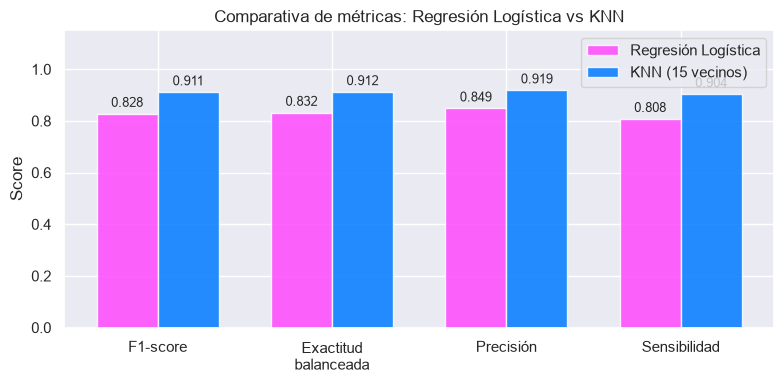

In [13]:
metric_labels = ["F1-score", "Exactitud\nbalanceada", "Precisión", "Sensibilidad"]
x = np.arange(len(metric_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 4))
bars_lr = ax.bar(x - width / 2, df_cmp.iloc[0], width, label="Regresión Logística",
                 color="#ff48fd", alpha=0.85)
bars_knn = ax.bar(x + width / 2, df_cmp.iloc[1], width, label="KNN (15 vecinos)",
                  color="#007aff", alpha=0.85)

ax.set_ylim(0, 1.15)
ax.set_xticks(x)
ax.set_xticklabels(metric_labels)
ax.set_ylabel("Score")
ax.set_title("Comparativa de métricas: Regresión Logística vs KNN")
ax.legend()
ax.bar_label(bars_lr, fmt="%.3f", padding=3, fontsize=9)
ax.bar_label(bars_knn, fmt="%.3f", padding=3, fontsize=9)

plt.tight_layout()
plt.show()

### Frontera de decisión

Como el dataset es 2D, podemos visualizar directamente las fronteras de decisión de cada modelo. Observá cómo la regresión logística traza una única línea recta que no puede capturar la forma de las lunas, mientras que kNN construye una frontera curva que sigue la estructura real de los datos.

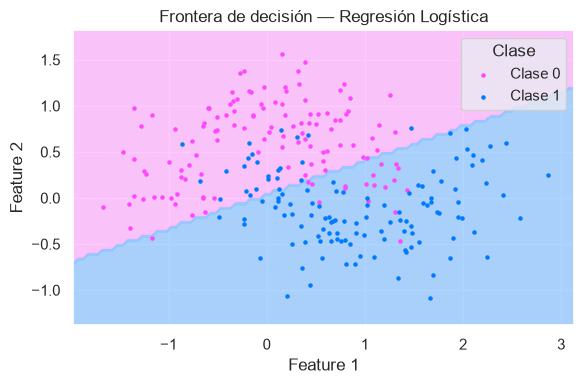

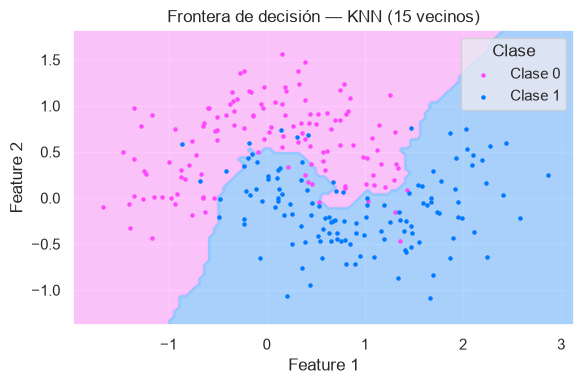

In [14]:
from auxiliary import plot_boundary

colormap_frontier = ("#ffb7fe", "#93c7ff")
colormap_points = ("#ff48fd", "#007aff")

for model, title in [
    (model_logistic, "Regresión Logística"),
    (classifier_knn, "KNN (15 vecinos)"),
]:
    plot_boundary(
        X_test, y_test, model,
        colormap_frontier=colormap_frontier,
        colormap_points=colormap_points,
        label_point=("Clase 0", "Clase 1"),
        labels_axis=("Feature 1", "Feature 2"),
        legend_title="Clase",
        step_x=(0.05, 0.05),
        min_x=(-0.3, -0.3),
        max_x=(0.3, 0.3),
        figsize=(6, 4),
    )
    plt.title(f"Frontera de decisión — {title}")
    plt.tight_layout()
    plt.show()